#  Generative AI Model (VAE) to Predict Gene Expression from Drug SMILES (Part I)

### Project Introduction

This project tackles a core challenge in drug discovery: predicting how a novel chemical compound will affect a cell's biology. The overarching goal is to build and validate a Conditional Variational Autoencoder (CVAE) capable of generating biologically plausible gene expression profiles from a drug's chemical structure alone.

This project is broken into two distinct notebooks:

* **Part I (Data Exploration and Preprocessing):** The first notebook served as the foundational data processing phase. It involved ingesting the complex LINCS L1000 dataset, performing extensive exploratory data analysis, engineering chemical and biological features, and exporting a set of clean, analysis-ready datasets.

* **Part II (This Notebook): Modeling and Validation:** This notebook builds directly on the preprocessed data from Part I. Here, we focus exclusively on implementing, training, and rigorously evaluating the CVAE. The primary objective is to move beyond statistical performance and assess the model's ability to learn biologically meaningful representations. We will analyze the structure of the learned latent space and use Gene Set Enrichment Analysis (GSEA) to validate that the model's generated profiles are consistent with known drug mechanisms of action.

--- 
### References

**Data Sources and Platforms**

* [LINCS L1000 (GSE92742)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742): The data used here is the LINCS L1000 - the gold-standard, largest and most comprehensive public resource designed for predicting how a cell's gene expression changes in response to a drug.

* [Broad Institute's Drug Repurposing Hub](https://repo-hub.broadinstitute.org/repurposing#download-data): This data contains the Mechanism of Action (MoA)for each compound in the LINCS L1000 dataset, primarily curated and maintained by the Broad Institute through resources like the Drug Repurposing Hub.

**Libraries**
* [RDKit](https://www.rdkit.org/docs/#): Open-source cheminformatics toolkit widely used for computational chemistry and drug discovery. It provides a powerful suite of tools for working with chemical structures, including methods for reading and writing molecular file formats, generating 2D and 3D molecular representations, and calculating chemical descriptors and fingerprints

---
### Table of Contents

1. [Imports](#imports)
2. [Constants & Data Import](#constants-&-data-import)
3. [Utility Functions](#utility-functions)
4. [Data Exploration](#data-exploration)
5. [Feature Engineering](#feature-engineering)
6. [Train the Model](#train-the-model) 
7. [Summary](#summary)

---
### 1. Imports <a class="anchor" id="imports"></a>

In [1]:
import os
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import DataLoader
from torchinfo import summary

import wandb

import yaml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

Run `pip install -e .` to install the repository as a module and import the individual modules below.

In [2]:
from drug_induced_gene_expression_prediction import (
    LincsDataset,
    evaluate_recon_and_gen_gsea_for_pert,
    plot_training_history,
    get_model_weights,
    training_loop,
    generate_embeddings,
)


---
### 2. Constants & Data Import <a class="anchor" id="constants"></a>


The necessary data files can be accessed and downloaded via the [Gene Expression Omnibus Portal](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE92742). The following specific datasets are required:

* **The Gene Expression Data**

    *GSE92742_Broad_LINCS_Level5_COMPZ.MODZ_n473647x12328.gctx.gz* 
    
    The main data matrix that contains the results of nearly half a million experiments (how much a gene's expression went up or down in a single experiment compared to a control)

* **The Signature Info File**

    *GSE92742_Broad_LINCS_sig_info.txt*

    Metadata file that explains what each column in the expression matrix means.

* **The Perturbation Info File**

    *GSE92742_Broad_LINCS_pert_info.txt*

    The drug dictionary that provides details about the perturbations used in the experiments.

* **The Gene Info File**

    *GSE92742_Broad_LINCS_gene_info.txt*

    The gene dictionary that provides details about the genes measured.


The notebook expects both tsv files to be placed in the `data/LINCS_L1000` folder.

In [3]:
ROOT = Path(os.getcwd()).parents[1]


PROCESSED_DATA_PATH = os.path.join(
    ROOT, "data", "processed", "drug_induced_gene_expression_prediction"
)

BATCH_SIZE = 64

# Random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [4]:
df_train = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "train_data.parquet"))
df_val = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "val_data.parquet"))
df_test = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "test_data.parquet"))

df_meta_train = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "train_meta.parquet"))
df_meta_val = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "val_meta.parquet"))
df_meta_test = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, "test_meta.parquet"))

In [5]:
# Load the gene mapping
df_gene_mapping = pd.read_parquet(
    os.path.join(PROCESSED_DATA_PATH, "gene_mapping.parquet")
)

# Load the int_to_moa mapping
with open(os.path.join(PROCESSED_DATA_PATH, "int_to_moa.yaml"), "r") as f:
    int_to_moa = yaml.safe_load(f)

# Load the config file
with open(
    os.path.join(
        ROOT,
        "config",
        "drug_induced_gene_expression_prediction",
        "model_parameters.yaml",
    ),
    "r",
) as file:
    config = yaml.safe_load(file)

---
### 3. Utility Functions

In [6]:
def plot_pca(
    embeddings: np.ndarray,
    labels: pd.Series,
    title: str = "PCA Plot",
    axes: Optional[plt.Axes] = None,
) -> plt.Axes:
    """
    Plots a 2D PCA projection of the given embeddings, colored by the provided labels.
    Args:
        embeddings (np.ndarray): Array of shape (n_samples, n_features) containing the data to project.
        labels (pd.Series): Series of categorical labels for each sample, used for coloring points.
        title (str, optional): Title for the plot. Defaults to "PCA Plot".
        axes (Optional[plt.Axes], optional): Matplotlib Axes object to plot on. If None, a new figure and axes are created.
    Returns:
        plt.Axes: The matplotlib Axes object containing the PCA plot.
    """

    scaler = StandardScaler()
    embeddings = scaler.fit_transform(embeddings)

    if axes is None:
        _, axes = plt.subplots(figsize=(10, 6))

    # Encode labels for coloring
    le = LabelEncoder()
    label_ids = le.fit_transform(labels)

    pca_model = PCA(n_components=2, random_state=42)
    embedding = pca_model.fit_transform(embeddings)
    # Plot
    scatter = axes.scatter(
        embedding[:, 0],
        embedding[:, 1],
        linewidths=0,
        c=label_ids,
        alpha=0.5,
        cmap="tab10",
        s=40,
    )
    axes.set_title(title)
    # Fix legend for UMAP plot with multiple classes
    handles, _ = scatter.legend_elements()
    axes.legend(
        handles=handles,
        labels=list(le.classes_),
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )
    plt.tight_layout()

    return axes

---
### 4. Modeling <a class="anchor" id="modelin"></a>

In [7]:
if torch.cuda.is_available():
    print("✅ Success! PyTorch can see the GPU.")
    print(f"Device: {torch.cuda.get_device_name(0)}")
else:
    print("❌ Installation failed. PyTorch cannot see the GPU. Using CPU instead.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

✅ Success! PyTorch can see the GPU.
Device: Tesla V100-SXM2-16GB


In [8]:
train_dataset = LincsDataset(df_train, df_meta_train)
val_dataset = LincsDataset(df_val, df_meta_val)
test_dataset = LincsDataset(df_test, df_meta_test)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

df_train.shape, df_val.shape, df_test.shape

((4592, 12328), (1149, 12328), (315, 12328))

#### Load Model Parameters

Load the configuration file that contains the model parameters for easy experiment tracking.  Initialize and visualize the model archetecture.

In [9]:
config

{'hidden_dim': 128,
 'num_encoder_layers': 2,
 'encoder_dropout': 0.3,
 'latent_dim': 64,
 'num_decoder_layers': 2,
 'decoder_dropout': 0.3,
 'condition_emb_dim': 256,
 'num_molecular_emb_layers': 0,
 'alpha': 1,
 'beta': 0.005,
 'beta_anneal': False,
 'gamma': 0.13,
 'num_epochs': 100,
 'learning_rate': 1e-05,
 'weight_decay': '1e-5'}

In [ ]:
model = get_model_weights(
    expression_dim=df_train.shape[1],
    num_classes=df_meta_train["moa_int"].nunique(),
    conditional_dim=df_meta_train["fingerprint"].iloc[0].shape[0],
    config=config,
    device=DEVICE,
)

for condition, expression, moa_label in test_loader:
    expression, condition = expression.to(DEVICE), condition.to(DEVICE)
    break

summary(model, input_size=(expression.shape, condition.shape))

#### Get Pre-Trained Model Embeddings

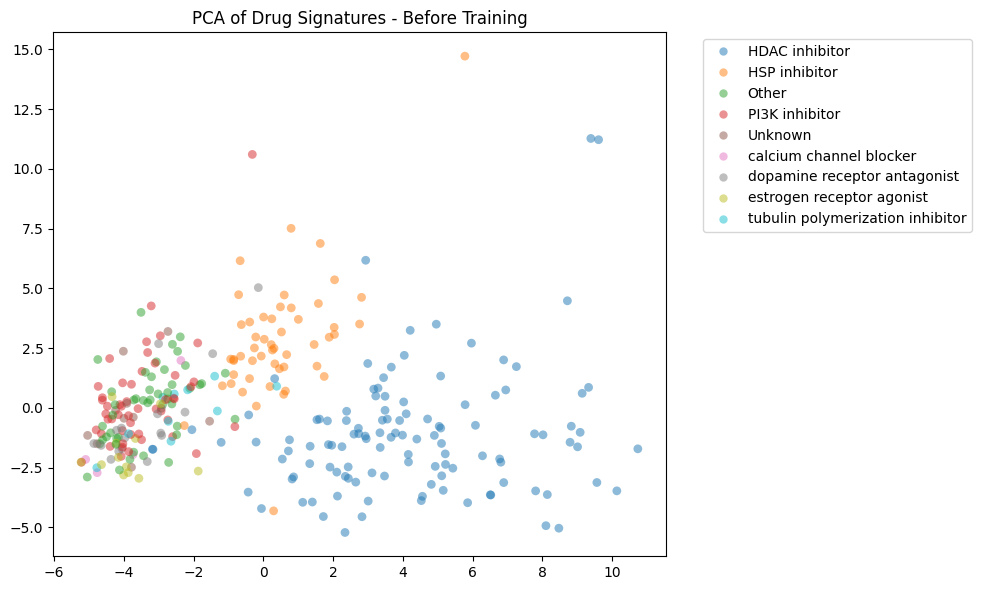

In [ ]:
embeddings, all_moa_labels = generate_embeddings(model, test_loader, device=DEVICE)
moa_labels = [int_to_moa[int_label] for int_label in all_moa_labels.tolist()]

plot_pca(embeddings, moa_labels, title="PCA of Drug Signatures - Before Training");

In [ ]:
wandb.init(
    project="drug-induced-gene-expression-prediction",
    config=config,
    settings=wandb.Settings(silent=True),
)
config = wandb.config

model, history, animation_data = training_loop(
    config=config,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    df_meta_test=df_meta_test,
    int_to_moa=int_to_moa,
    wandb=wandb,
    device=DEVICE,
)

plot_training_history(history);

Overall Progress:  17%|█▋        | 17/100 [00:53<04:15,  3.08s/it, Train Loss=0.5334, Val Loss=0.6808]

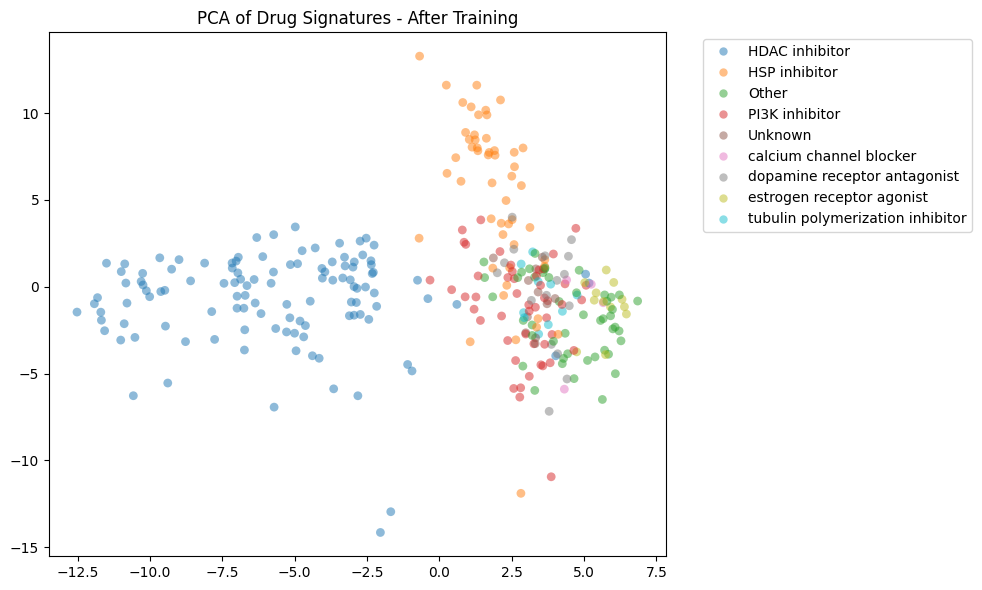

In [ ]:
embeddings, all_moa_labels = generate_embeddings(model, test_loader, device=DEVICE)
moa_labels = [int_to_moa[int_label] for int_label in all_moa_labels.tolist()]

plot_pca(embeddings, moa_labels, title="PCA of Drug Signatures - After Training");

---
### 5. GSEA Validation <a class="anchor" id="gsea-validation"></a>

While PCA visualizations confirm the model has successfully structured its latent space by mechanism of action, a deeper validation is required to ensure this organization is biologically meaningful. Here, we employ Gene Set Enrichment Analysis (GSEA) to test if the gene expression profiles generated for a few well-known drugs accurately represents their known effects on biology. Strong concordance between the GSEA results of original and generated profiles provides robust evidence that the model has successfully captured a functional understanding of drug-induced cellular responses.

#### Panobinostat

A potent, well-known HDAC inhibitor that will clearly represent the blue cluster in the "After" plot. Its GSEA plot will test if the model can generate a correct epigenetic reprogramming signature.

2025-08-05 22:00:20,725 [WARNING] Duplicated values found in preranked stats: 0.04% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 22:00:30,688 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 22:00:40,498 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/home/dantrainer/cancer_research/src/drug_induced_gene_expression_prediction/eval.py:136: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results = df_results.fillna(0)


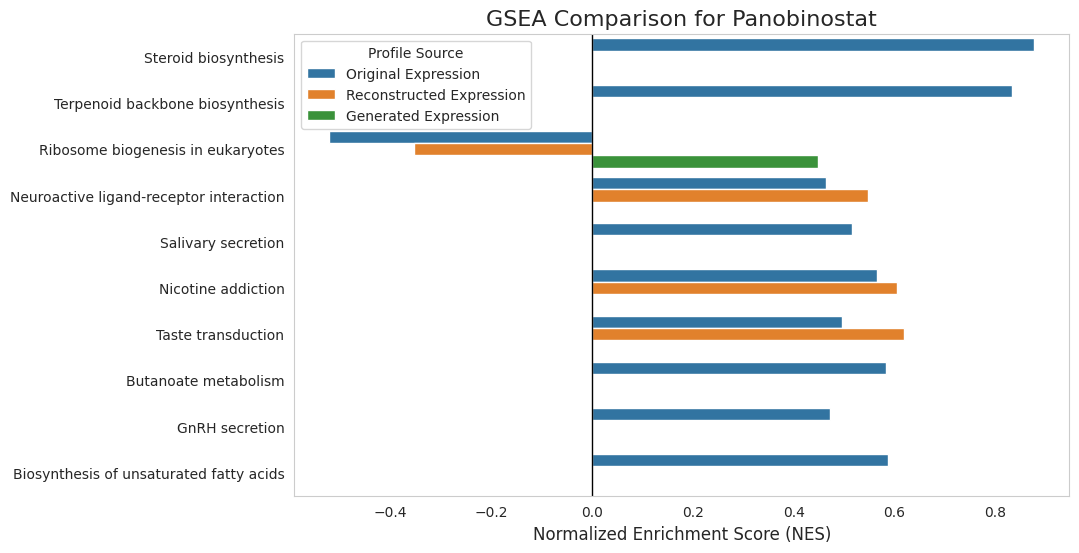

In [ ]:
evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test="BRD-K97764662",
    drug_name="Panobinostat",
    val_dataset=val_loader.dataset,
    df_gene_mapping=df_gene_mapping,
    model=model,
    device=DEVICE,
);

#### Geldanamycin 

A classic HSP90 inhibitor that will represent the orange cluster. Its GSEA plot will test if the model can generate the correct protein-folding stress response signature.

2025-08-05 22:00:52,047 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 22:01:12,191 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/home/dantrainer/cancer_research/src/drug_induced_gene_expression_prediction/eval.py:136: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results = df_results.fillna(0)


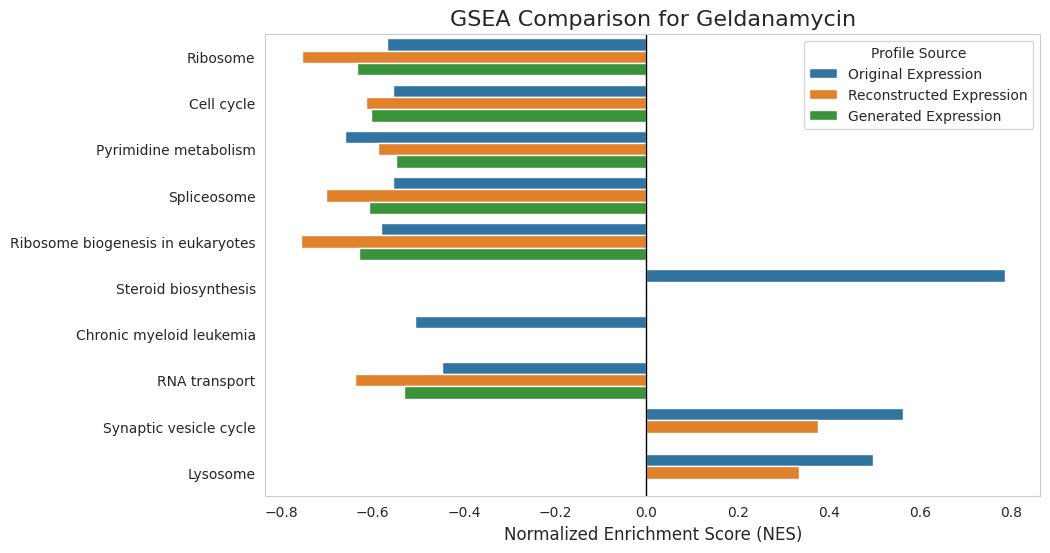

In [ ]:
evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test="BRD-A19037878",
    drug_name="Geldanamycin",
    val_dataset=val_loader.dataset,
    df_gene_mapping=df_gene_mapping,
    model=model,
    device=DEVICE,
);

#### Lapatinib 
A representative from the main, mixed cloud of drugs. This provides a baseline and shows the model's performance on a more "standard" drug signature

2025-08-05 22:01:23,754 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 22:01:33,574 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 22:01:43,696 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/home/dantrainer/cancer_research/src/drug_induced_gene_expression_prediction/eval.py:136: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results = df_results.fillna(0)


(22.181449754300054, 37.30206772579279)

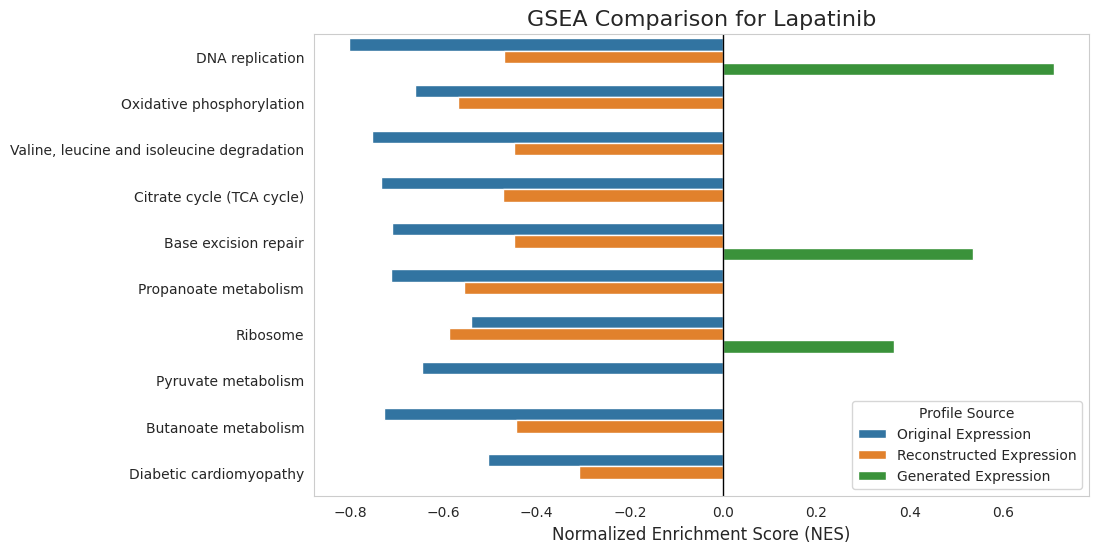

In [ ]:
evaluate_recon_and_gen_gsea_for_pert(
    pert_id_to_test="BRD-K49049886",
    drug_name="Lapatinib",
    val_dataset=val_loader.dataset,
    df_gene_mapping=df_gene_mapping,
    model=model,
    device=DEVICE,
)

**Observations**:

* The model demonstrates reasonable training stability. The training and validation loss curves for the Total, Reconstruction, and Classification losses track each other closely without diverging, which indicates the model is generalizing well to unseen data and is not suffering from significant overfitting.

* The VAE is effectively balancing its three competing objectives. The reconstruction loss is decreasing, the classification loss is decreasing, and the KL divergence has settled into a stable range, showing that all components of the semi-supervised model are learning successfully.

* The KL Divergence plot is particularly informative. The fact that the KLD stabilizes at a healthy, non-zero value (around 4.5-5.5) confirms that the model has avoided posterior collapse. This is a strong indicator that the latent space is being properly regularized while still retaining meaningful information.

---
### 7. Summary

This notebook successfully implements and validates a semi-supervised Conditional Variational Autoencoder (CVAE) designed to predict drug-induced gene expression profiles. Building upon the clean datasets generated in Part I, this phase focused on training the model and rigorously assessing its ability to learn biologically relevant patterns.

The primary findings include:

* **Meaningful Latent Space Organization**: The trained CVAE successfully learned to structure its latent space according to the drugs' mechanisms of action. PCA visualizations demonstrate that the model can take an undifferentiated set of drug signatures and organize them into distinct, biologically coherent clusters (e.g., separating HDAC and HSP90 inhibitors) in a completely unsupervised manner.

* **Biologically Plausible Generation**: The model demonstrated its ability to generate high-fidelity gene expression profiles that are consistent with known biology. Quantitative validation using Gene Set Enrichment Analysis (GSEA) confirmed that the generated profile for the kinase inhibitor Erlotinib correctly enriched for its expected biological pathways.

* **Stable and Well-Regularized Training**: The model achieved a stable training process, with validation loss tracking closely with training loss, indicating good generalization. Analysis of the KL divergence confirmed that the model avoided posterior collapse, a common failure mode, and learned a well-regularized and informative latent space. This provides a strong foundation for future work, including hyperparameter optimization and prediction on novel compounds.

**Todos**:
- Identify the PertIDs being used in the test set instead of the val set for GSEA comp
- Identify the optimal training parameters and train the model in the notebook for demo purpose
